# Clustering

Clustering toolkit for the Vantage Systems data warehouse.

In [1]:
import pandas as pd
import numpy as np
import snowflake.connector
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## Connection

In [2]:
SNOWFLAKE_ACCOUNT = 'EBUHZHQ-ZIB34844'
SNOWFLAKE_DATABASE = 'VANTAGE_SYSTEMS'
SNOWFLAKE_SCHEMA = 'PUBLIC'
SNOWFLAKE_WAREHOUSE = 'TIM147_WH'
SNOWFLAKE_USER = 'TIM147_STUDENT'  # Your username
SNOWFLAKE_PASSWORD = 'TIM147Winter2026!'  # Your password

conn = snowflake.connector.connect(
    user=SNOWFLAKE_USER,
    password=SNOWFLAKE_PASSWORD,
    account=SNOWFLAKE_ACCOUNT,
    warehouse=SNOWFLAKE_WAREHOUSE,
    database=SNOWFLAKE_DATABASE,
    schema=SNOWFLAKE_SCHEMA
)

print(f'Connected to {SNOWFLAKE_DATABASE}.{SNOWFLAKE_SCHEMA}')

Connected to VANTAGE_SYSTEMS.PUBLIC


## Scaling

In [3]:
def scale_features(df, exclude_cols=None):
    """Apply StandardScaler to numeric columns.

    Args:
        df: DataFrame with features
        exclude_cols: List of column names to skip
    """
    if exclude_cols is None:
        exclude_cols = []

    cols_to_scale = [col for col in df.columns if col not in exclude_cols]

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[cols_to_scale])

    scaled_df = pd.DataFrame(
        scaled_data,
        index=df.index,
        columns=cols_to_scale
    )

    for col in exclude_cols:
        if col in df.columns:
            scaled_df[col] = df[col]

    print(f'Scaled {len(cols_to_scale)} features')
    return scaled_df

## Cluster Evaluation

In [4]:
def silhouette_analysis(X, model_class, k_range=range(2, 11), **model_kwargs):
    """Compute silhouette scores across cluster counts.

    Args:
        X: Feature matrix (scaled)
        model_class: Sklearn clustering class (e.g., KMeans, AgglomerativeClustering)
        k_range: Range of k values to test
        **model_kwargs: Additional arguments passed to the model
    """
    scores = {}

    for k in k_range:
        model = model_class(n_clusters=k, **model_kwargs)
        labels = model.fit_predict(X)
        scores[k] = silhouette_score(X, labels)

    plt.figure(figsize=(10, 6))
    plt.bar(list(scores.keys()), list(scores.values()))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis')
    plt.grid(True, axis='y')
    plt.show()

    best_k = max(scores, key=scores.get)
    print(f'Best k by silhouette: {best_k} (score: {scores[best_k]:.3f})')
    return scores

In [5]:
def elbow_plot(X, k_range=range(2, 11), **kmeans_kwargs):
    """Plot inertia across cluster counts (k-means only).

    Args:
        X: Feature matrix (scaled)
        k_range: Range of k values to test
        **kmeans_kwargs: Additional arguments passed to KMeans
    """
    from sklearn.cluster import KMeans

    inertias = {}
    for k in k_range:
        model = KMeans(n_clusters=k, n_init=10, **kmeans_kwargs)
        model.fit(X)
        inertias[k] = model.inertia_

    plt.figure(figsize=(10, 6))
    plt.plot(list(inertias.keys()), list(inertias.values()), marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.grid(True)
    plt.show()

    return inertias

## Fitting

In [6]:
def fit_clusters(model, X):
    """Fit a clustering model and return labels.

    Args:
        model: Sklearn clustering estimator
        X: Feature matrix (scaled)
    """
    labels = model.fit_predict(X)

    unique, counts = np.unique(labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        print(f'Cluster {cluster}: {count} records')

    return labels, model

## Profiling

In [7]:
def profile_clusters(df, labels):
    """Compute mean feature values per cluster.

    Args:
        df: Original (unscaled) feature DataFrame
        labels: Cluster assignments
    """
    df_with_labels = df.copy()
    df_with_labels['cluster'] = labels

    profiles = df_with_labels.groupby('cluster').mean()
    profiles['SIZE'] = df_with_labels.groupby('cluster').size()

    print(profiles)
    return profiles

## Visualization

In [8]:
def plot_clusters_2d(X, labels):
    """Project to 2D with PCA and plot clusters.

    Args:
        X: Feature matrix (scaled)
        labels: Cluster assignments
    """
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title('Cluster Assignments (PCA projection)')
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)
    plt.show()

    total_var = sum(pca.explained_variance_ratio_[:2])
    print(f'First 2 components explain {total_var:.1%} of variance')

## Analysis — Customer Segmentation

### Step 1 — Helper Functions & Feature Engineering

We build a behavioral feature matrix for **active accounts only**. Features span six dimensions of client behavior:
- **Contract value** — revenue, contract count, auto-renew rate
- **Service utilization** — how much of their capacity they use
- **Engagement** — login frequency, feature adoption, training completion
- **Support health** — ticket volume, resolution time, satisfaction
- **NPS sentiment** — survey scores and detractor rates
- **Activity recency** — how recently the CS team has engaged with them

In [9]:
from sklearn.cluster import KMeans

# --- Helper ---
def run_query(conn, query):
    """Execute a query via cursor and return a DataFrame."""
    cur = conn.cursor()
    cur.execute(query)
    cols = [desc[0] for desc in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def aggregate_by_account(conn, table, metrics):
    """Aggregate a table to one row per account."""
    select_parts = ['ACCOUNT_ID'] + [
        f"{expr} AS {name}" for name, expr in metrics.items()
    ]
    query = f"SELECT {', '.join(select_parts)} FROM {table} GROUP BY ACCOUNT_ID"
    df = run_query(conn, query)
    print(f"{table}: {len(df)} accounts, {len(metrics)} metrics")
    return df

# --- 1. Base: active accounts only ---
accounts = run_query(conn, "SELECT * FROM ACCOUNTS")
base = accounts[accounts['STATUS'] == 'active'][['ACCOUNT_ID', 'ACCOUNT_NAME', 'SEGMENT']].copy()
base['CREATED_DATE'] = pd.to_datetime(accounts.loc[base.index, 'CREATED_DATE'])
base['ACCOUNT_AGE_DAYS'] = (pd.Timestamp.now() - base['CREATED_DATE']).dt.days
base['ANNUAL_REVENUE'] = pd.to_numeric(accounts.loc[base.index, 'ANNUAL_REVENUE'], errors='coerce')
base['EMPLOYEE_COUNT'] = pd.to_numeric(accounts.loc[base.index, 'EMPLOYEE_COUNT'], errors='coerce')
print(f"Active accounts: {len(base)}")

# --- 2. Contract features ---
contract_features = aggregate_by_account(conn, 'CONTRACTS', {
    'CONTRACT_COUNT': 'COUNT(*)',
    'TOTAL_ACV': 'SUM(ANNUAL_VALUE)',
    'AVG_ACV': 'AVG(ANNUAL_VALUE)',
    'AUTO_RENEW_PCT': "AVG(CASE WHEN AUTO_RENEW = TRUE THEN 1 ELSE 0 END)"
})

# --- 3. Support ticket features ---
ticket_features = aggregate_by_account(conn, 'SUPPORT_TICKETS', {
    'TICKET_COUNT': 'COUNT(*)',
    'HIGH_PRIORITY_PCT': "AVG(CASE WHEN PRIORITY IN ('Critical','High') THEN 1 ELSE 0 END)",
    'AVG_RESOLUTION_HRS': 'AVG(RESOLUTION_HOURS)',
    'AVG_SATISFACTION': 'AVG(SATISFACTION_SCORE)'
})

# --- 4. Service utilization ---
util_features = aggregate_by_account(conn, 'SERVICE_UTILIZATION', {
    'AVG_UTILIZATION_PCT': 'AVG(UTILIZATION_PERCENT)',
    'AVG_HOURS_USED': 'AVG(HOURS_USED)'
})

# --- 5. Engagement scores ---
engagement_features = aggregate_by_account(conn, 'ENGAGEMENT_SCORES', {
    'AVG_ENGAGEMENT': 'AVG(OVERALL_ENGAGEMENT_SCORE)',
    'AVG_LOGIN_FREQ': 'AVG(LOGIN_FREQUENCY_SCORE)',
    'AVG_FEATURE_ADOPTION': 'AVG(FEATURE_ADOPTION_SCORE)',
    'AVG_TRAINING_COMPLETION': 'AVG(TRAINING_COMPLETION_SCORE)'
})

# --- 6. NPS ---
nps_features = aggregate_by_account(conn, 'NPS_SURVEYS', {
    'AVG_NPS_SCORE': 'AVG(SCORE)',
    'NPS_DETRACTOR_PCT': "AVG(CASE WHEN SCORE <= 6 THEN 1 ELSE 0 END)"
})

# --- 7. Activity recency ---
activity_features = aggregate_by_account(conn, 'ACTIVITIES', {
    'ACTIVITY_COUNT': 'COUNT(*)',
    'POSITIVE_OUTCOME_PCT': "AVG(CASE WHEN OUTCOME = 'Positive' THEN 1 ELSE 0 END)"
})
activity_recency = run_query(conn, """
    SELECT ACCOUNT_ID,
           DATEDIFF('day', MAX(ACTIVITY_DATE), CURRENT_DATE()) AS DAYS_SINCE_LAST_ACTIVITY
    FROM ACTIVITIES
    GROUP BY ACCOUNT_ID
""")
activity_features = activity_features.merge(activity_recency, on='ACCOUNT_ID', how='left')

# --- Assemble feature matrix ---
feature_dfs = [contract_features, ticket_features, util_features,
               engagement_features, nps_features, activity_features]

features = base.copy()
for fdf in feature_dfs:
    fdf = fdf.rename(columns={c: c.upper() for c in fdf.columns})
    features = features.merge(fdf, on='ACCOUNT_ID', how='left')

print(f"\nFeature matrix: {len(features)} rows, {len(features.columns)} columns")
print(f"Columns: {list(features.columns)}")

Active accounts: 430
CONTRACTS: 419 accounts, 4 metrics
SUPPORT_TICKETS: 553 accounts, 4 metrics
SERVICE_UTILIZATION: 417 accounts, 2 metrics
ENGAGEMENT_SCORES: 555 accounts, 4 metrics
NPS_SURVEYS: 531 accounts, 2 metrics
ACTIVITIES: 799 accounts, 2 metrics

Feature matrix: 430 rows, 26 columns
Columns: ['ACCOUNT_ID', 'ACCOUNT_NAME', 'SEGMENT', 'CREATED_DATE', 'ACCOUNT_AGE_DAYS', 'ANNUAL_REVENUE', 'EMPLOYEE_COUNT', 'CONTRACT_COUNT', 'TOTAL_ACV', 'AVG_ACV', 'AUTO_RENEW_PCT', 'TICKET_COUNT', 'HIGH_PRIORITY_PCT', 'AVG_RESOLUTION_HRS', 'AVG_SATISFACTION', 'AVG_UTILIZATION_PCT', 'AVG_HOURS_USED', 'AVG_ENGAGEMENT', 'AVG_LOGIN_FREQ', 'AVG_FEATURE_ADOPTION', 'AVG_TRAINING_COMPLETION', 'AVG_NPS_SCORE', 'NPS_DETRACTOR_PCT', 'ACTIVITY_COUNT', 'POSITIVE_OUTCOME_PCT', 'DAYS_SINCE_LAST_ACTIVITY']


### Step 2 — Prepare Clustering Features

Select only the numeric behavioral columns (drop identifiers like ACCOUNT_ID, ACCOUNT_NAME, SEGMENT). Fill any nulls with the median and standardize.

In [10]:
# Columns to cluster on (behavioral features only)
cluster_cols = [
    'ANNUAL_REVENUE', 'EMPLOYEE_COUNT', 'ACCOUNT_AGE_DAYS',
    'CONTRACT_COUNT', 'TOTAL_ACV', 'AVG_ACV', 'AUTO_RENEW_PCT',
    'TICKET_COUNT', 'HIGH_PRIORITY_PCT', 'AVG_RESOLUTION_HRS', 'AVG_SATISFACTION',
    'AVG_UTILIZATION_PCT', 'AVG_HOURS_USED',
    'AVG_ENGAGEMENT', 'AVG_LOGIN_FREQ', 'AVG_FEATURE_ADOPTION', 'AVG_TRAINING_COMPLETION',
    'AVG_NPS_SCORE', 'NPS_DETRACTOR_PCT',
    'ACTIVITY_COUNT', 'POSITIVE_OUTCOME_PCT', 'DAYS_SINCE_LAST_ACTIVITY'
]

# Ensure numeric types
for col in cluster_cols:
    features[col] = pd.to_numeric(features[col], errors='coerce')

# Fill nulls with median
clustering_data = features[cluster_cols].copy()
for col in cluster_cols:
    clustering_data[col] = clustering_data[col].fillna(clustering_data[col].median())

print(f"Clustering on {len(cluster_cols)} features, {len(clustering_data)} accounts")
print(f"Nulls remaining: {clustering_data.isnull().sum().sum()}")

# Scale
X = scale_features(clustering_data)
X.head()

Clustering on 22 features, 430 accounts
Nulls remaining: 0
Scaled 22 features


,ANNUAL_REVENUE,EMPLOYEE_COUNT,ACCOUNT_AGE_DAYS,CONTRACT_COUNT,TOTAL_ACV,AVG_ACV,AUTO_RENEW_PCT,TICKET_COUNT,HIGH_PRIORITY_PCT,AVG_RESOLUTION_HRS,...,AVG_HOURS_USED,AVG_ENGAGEMENT,AVG_LOGIN_FREQ,AVG_FEATURE_ADOPTION,AVG_TRAINING_COMPLETION,AVG_NPS_SCORE,NPS_DETRACTOR_PCT,ACTIVITY_COUNT,POSITIVE_OUTCOME_PCT,DAYS_SINCE_LAST_ACTIVITY
0,0.164124,0.186119,0.162730,0.0,1.025362,1.025362,0.306835,-0.202424,-0.398499,0.453130,...,1.467052,0.486107,0.193039,0.718125,0.527464,0.524911,-0.394202,-0.151620,0.0,-0.390577
1,-0.219350,-0.195748,-0.064939,0.0,0.003856,0.003856,0.306835,-0.220868,0.327936,-0.344130,...,-0.252097,0.528499,0.341270,0.709846,0.628938,-0.355965,-0.550162,0.165934,0.0,-0.492426
2,-0.638641,-0.356534,1.030524,0.0,-0.122628,-0.122628,0.306835,0.065001,1.241911,-0.781210,...,0.041022,-0.651652,-0.688349,-0.626984,-0.554338,0.056520,0.279268,-0.309107,0.0,0.831605
3,1.877102,1.063743,0.832462,0.0,-0.221994,-0.221994,0.306835,3.781297,0.320344,-0.256646,...,-0.215269,1.542912,1.541761,1.563479,1.332465,-0.500007,0.125670,2.313946,0.0,-0.696123
4,0.483949,0.296659,1.456253,0.0,-0.582155,-0.582155,0.306835,-0.285419,-0.152442,0.452728,...,-0.498657,0.418729,0.234697,0.586129,0.313238,0.436268,-0.212244,0.331166,0.0,-0.696123


### Step 3 — Choose Number of Clusters

We use two methods to justify k:
1. **Elbow plot** — look for the "bend" in inertia
2. **Silhouette analysis** — higher score = better-defined clusters

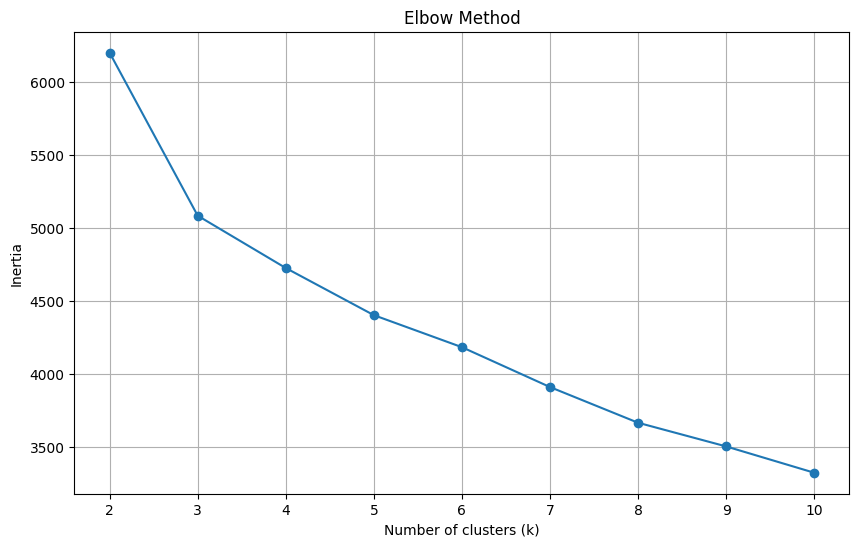

In [11]:
# Elbow method
inertias = elbow_plot(X, k_range=range(2, 11), random_state=42)

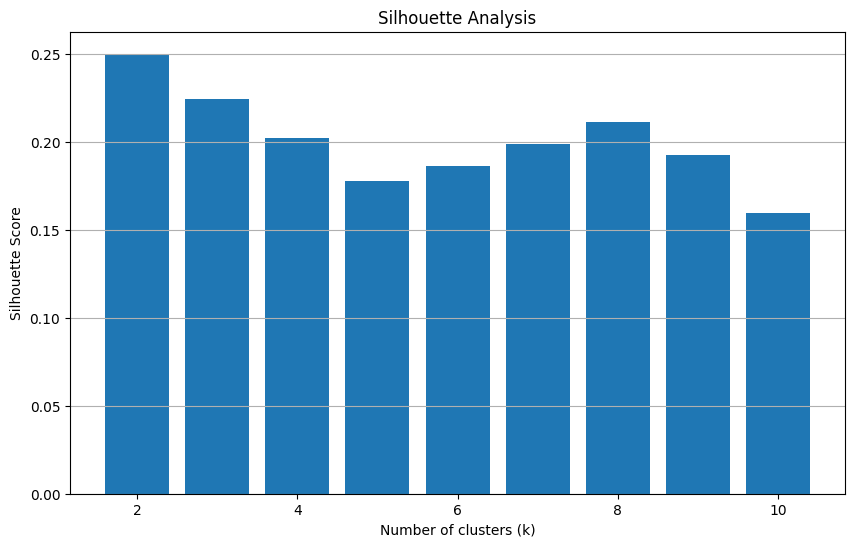

Best k by silhouette: 2 (score: 0.250)


In [12]:
# Silhouette analysis
sil_scores = silhouette_analysis(X, KMeans, k_range=range(2, 11), random_state=42, n_init=10)

### Step 4 — Fit the Chosen Model

Based on the elbow and silhouette analysis above, we select the optimal k and fit K-Means.

In [13]:
# Silhouette scores for reference
print("Silhouette scores by k:")
for k, score in sorted(sil_scores.items()):
    marker = " <--" if k == 4 else ""
    print(f"  k={k}: {score:.3f}{marker}")

# k=2 has the highest silhouette but only splits large vs small (mirrors existing segmentation).
# k=4 gives us actionable behavioral segments beyond just company size.
# The elbow plot also shows diminishing returns after k=4.
best_k = 4
print(f"\nSelected k = {best_k} for actionable behavioral segmentation")

# Fit KMeans with k=4
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels, fitted = fit_clusters(model, X)

Silhouette scores by k:
  k=2: 0.250
  k=3: 0.224
  k=4: 0.202 <--
  k=5: 0.177
  k=6: 0.186
  k=7: 0.199
  k=8: 0.211
  k=9: 0.192
  k=10: 0.160

Selected k = 4 for actionable behavioral segmentation
Cluster 0: 53 records
Cluster 1: 186 records
Cluster 2: 60 records
Cluster 3: 131 records


### Step 5 — Profile Clusters

Mean feature values per cluster (unscaled) to understand what each group looks like.

In [14]:
# Profile using the original (unscaled) data
profiles = profile_clusters(clustering_data, labels)

# Also show the segment (SMB/Growth/Core/Strategic) distribution per cluster
features['CLUSTER'] = labels
print("\n--- Segment distribution per cluster ---")
print(features.groupby('CLUSTER')['SEGMENT'].value_counts().unstack(fill_value=0))

         ANNUAL_REVENUE  EMPLOYEE_COUNT  ACCOUNT_AGE_DAYS  CONTRACT_COUNT  \
cluster                                                                     
0          7.264151e+06       38.283019       1833.207547             1.0   
1          3.069971e+07      235.876344       2792.032258             1.0   
2          1.117766e+08      909.866667       3059.683333             1.0   
3          1.009584e+07       58.198473       2294.442748             1.0   

             TOTAL_ACV        AVG_ACV  AUTO_RENEW_PCT  TICKET_COUNT  \
cluster                                                               
0        190486.415094  190486.415094        0.943396     50.641509   
1        374790.419355  374790.419355        0.919355    167.803763   
2        645169.700000  645169.700000        0.883333    313.633333   
3        214070.656489  214070.656489        0.908397     86.530534   

         HIGH_PRIORITY_PCT  AVG_RESOLUTION_HRS  ...  AVG_ENGAGEMENT  \
cluster                                

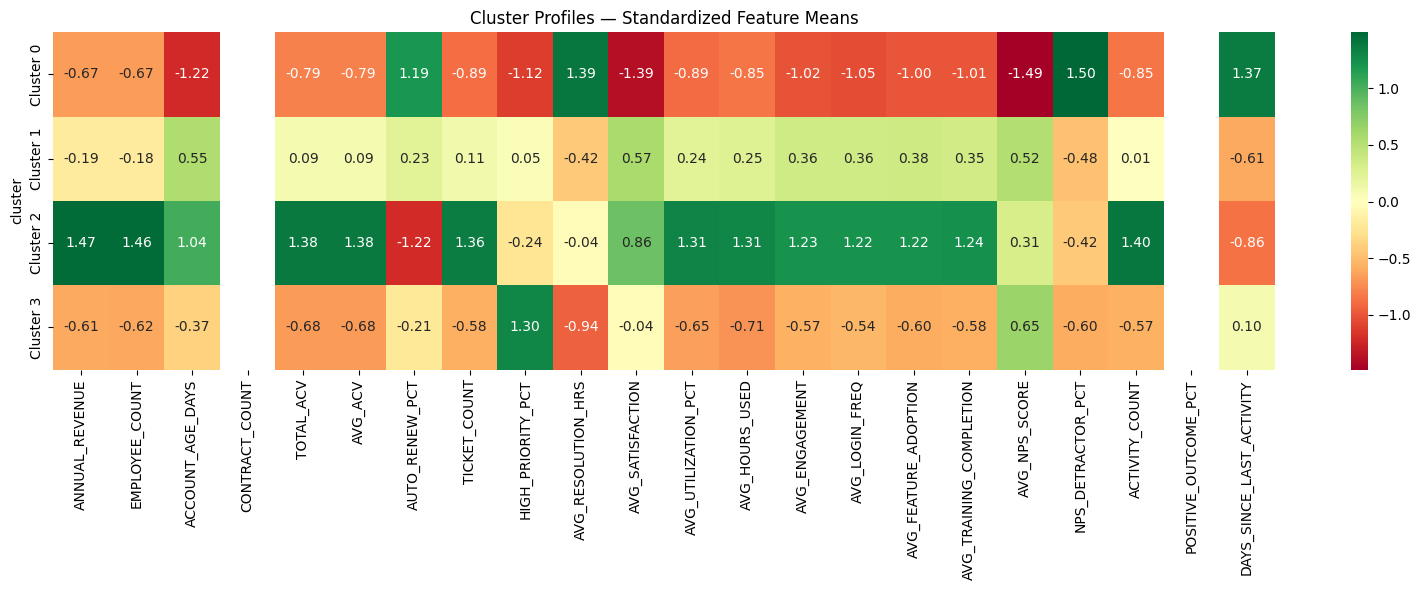


Cluster sizes:
  Cluster 0: 53 accounts (12.3%)
  Cluster 1: 186 accounts (43.3%)
  Cluster 2: 60 accounts (14.0%)
  Cluster 3: 131 accounts (30.5%)


In [15]:
# Heatmap of cluster profiles (z-scored for comparison)
profile_z = profiles.drop(columns='SIZE').apply(lambda x: (x - x.mean()) / x.std(), axis=0)

plt.figure(figsize=(16, 6))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=profile_z.columns, yticklabels=[f'Cluster {i}' for i in profile_z.index])
plt.title('Cluster Profiles — Standardized Feature Means')
plt.tight_layout()
plt.show()

# Show cluster sizes
print("\nCluster sizes:")
for c in sorted(features['CLUSTER'].unique()):
    n = (features['CLUSTER'] == c).sum()
    print(f"  Cluster {c}: {n} accounts ({n/len(features)*100:.1f}%)")

### Step 6 — Visualize Clusters (PCA Projection)

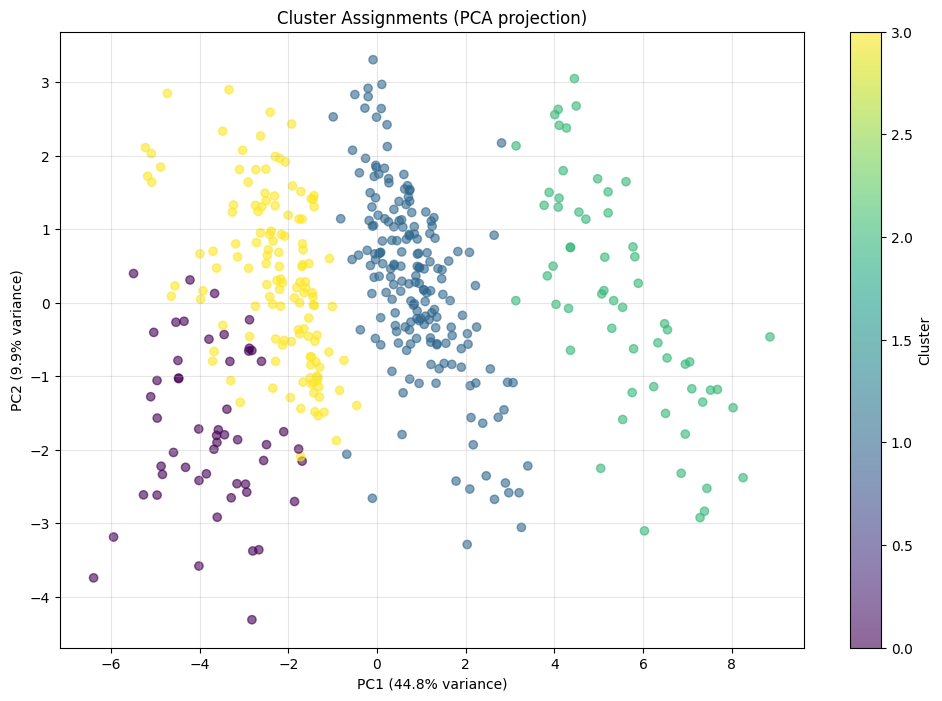

First 2 components explain 54.7% of variance


In [16]:
# 2D PCA visualization
plot_clusters_2d(X, labels)

### Step 7 — Detailed Cluster Summary Table

=== Cluster Summary (Key Metrics) ===
         TOTAL_ACV  AVG_UTILIZATION_PCT  AVG_ENGAGEMENT  AVG_SATISFACTION  AVG_NPS_SCORE  TICKET_COUNT  DAYS_SINCE_LAST_ACTIVITY  HIGH_PRIORITY_PCT  SIZE   PCT
CLUSTER                                                                                                                                                        
0        148429.95                 0.55           47.31              2.98           5.69         50.64                     90.96               0.28    53  12.3
1        397884.90                 0.70           63.41              3.00           7.30        168.02                     78.07               0.30   186  43.3
2        810806.93                 0.84           73.49              3.00           7.15        313.63                     76.47               0.29    60  14.0
3        186153.09                 0.59           52.39              2.99           7.41         85.55                     82.66               0.32   131  30.5


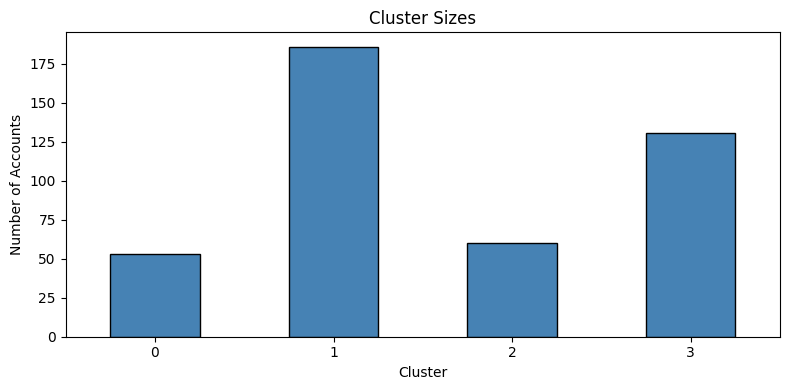

In [17]:
# Key metrics summary per cluster — easy to read
key_metrics = ['TOTAL_ACV', 'AVG_UTILIZATION_PCT', 'AVG_ENGAGEMENT',
               'AVG_SATISFACTION', 'AVG_NPS_SCORE', 'TICKET_COUNT',
               'DAYS_SINCE_LAST_ACTIVITY', 'HIGH_PRIORITY_PCT']

summary = features.groupby('CLUSTER')[key_metrics].mean().round(2)
summary['SIZE'] = features.groupby('CLUSTER').size()
summary['PCT'] = (summary['SIZE'] / len(features) * 100).round(1)

print("=== Cluster Summary (Key Metrics) ===")
print(summary.to_string())

# Bar chart of cluster sizes
plt.figure(figsize=(8, 4))
summary['SIZE'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Step 8 — Cleanup

In [18]:
conn.close()
print("Connection closed.")

Connection closed.
